In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [120]:
# List all CSV files in the 'datathon-2026-round-1' directory
csv_dir = 'datathon-2026-round-1'
csv_files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]

# Load each CSV file into a dataframe with variable name as the file name (without .csv)
for file in csv_files:
    var_name = os.path.splitext(file)[0]
    df = pd.read_csv(os.path.join(csv_dir, file))
    globals()[var_name] = df

/tmp/ipykernel_11331/2926216130.py:8: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(csv_dir, file))


In [3]:
print(returns[returns['product_id'] == 93])
inventory[(inventory["product_id"] == 2377)]

        return_id  order_id  product_id return_date     return_reason  \
284    RET-000361      5765          93  2012-08-09  not_as_described   
528    RET-000679     10817          93  2012-09-13      changed_mind   
963    RET-001252     19604          93  2012-10-13      changed_mind   
1092   RET-001418     22025          93  2012-10-19         defective   
1405   RET-001804     27565          93  2012-11-26        wrong_size   
1426   RET-001831     28227          93  2012-11-21         defective   
2427   RET-003138     47629          93  2013-03-01  not_as_described   
6889   RET-008926    137679          93  2014-01-09        wrong_size   
7626   RET-009897    153304          93  2014-04-04        wrong_size   
7778   RET-010104    157101          93  2014-04-01        wrong_size   
8877   RET-011512    179419          93  2014-06-03  not_as_described   
9114   RET-011813    184240          93  2014-06-20         defective   
13538  RET-017437    273064          93  2015-05-02

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
58541,2022-08-31,2377,3,1,1,0,90.0,1.0,0,0,0,0.25,VietMotion UC-25,Streetwear,Everyday,2022,8
58542,2022-09-30,2377,3,1,1,0,90.0,1.0,0,0,0,0.25,VietMotion UC-25,Streetwear,Everyday,2022,9
58543,2022-12-31,2377,3,1,1,0,90.0,1.0,0,0,0,0.25,VietMotion UC-25,Streetwear,Everyday,2022,12


In [105]:
orders['order_status'].value_counts()

order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64

In [ ]:
#Q1 - suwa lai sau
# orders = orders[orders['order_status'] == '']
print(orders)
multi_order = orders['customer_id'].value_counts()
multi_order = multi_order[multi_order > 1].index

orders_multi = orders[orders['customer_id'].isin(multi_order)].copy()

orders_multi['order_date'] = pd.to_datetime(orders_multi['order_date'])

orders_multi = orders_multi.sort_values(['customer_id', 'order_date'])

orders_multi['inter_order_gap'] = orders_multi.groupby('customer_id')['order_date'].diff().dt.days

median_gap = orders_multi['inter_order_gap'].median()
print(f"{median_gap:.0f}")

# Answer: ???180

        order_id  order_date  customer_id    zip order_status payment_method  \
0              1  2012-07-04        58578   1109    delivered    credit_card   
1              2  2012-07-04        58621   1330     returned            cod   
2              3  2012-07-04        58811   1473    delivered    credit_card   
3              4  2012-07-04        59453   2360    delivered    credit_card   
4              6  2012-07-06        57821   2886    delivered         paypal   
...          ...         ...          ...    ...          ...            ...   
646940    834372  2022-12-31        19490  33907    delivered    credit_card   
646941    834377  2022-12-31        73046  37091    delivered    credit_card   
646942    834387  2022-12-31       107723  80516    delivered    credit_card   
646943    834392  2022-12-31       139431  93510    delivered         paypal   
646944    834397  2022-12-31       136302  95678    delivered    credit_card   

       device_type    order_source  
0 

In [112]:
#Q2
products['gross_margin'] = (products['price'] - products['cogs']) / products['price']

segment_margin = products.groupby('segment')['gross_margin'].mean().sort_values(ascending=False)

top_segment = segment_margin.idxmax()
top_margin = segment_margin.max()
print(f"Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất: {top_segment} ({top_margin:.2%})")
print(segment_margin)
# Answer: Standard
print(80*'-')
category_margin = products.groupby('category')['gross_margin'].mean().sort_values(ascending=False)

top_segment = category_margin.idxmax()
top_margin = category_margin.max()
print(f"Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất: {top_segment} ({top_margin:.2%})")
print(category_margin)

Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất: Standard (31.34%)
segment
Standard       0.313442
Premium        0.285377
All-weather    0.284176
Activewear     0.265600
Performance    0.263650
Balanced       0.258038
Trendy         0.240758
Everyday       0.236343
Name: gross_margin, dtype: float64
--------------------------------------------------------------------------------
Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất: Casual (28.48%)
category
Casual        0.284754
Outdoor       0.269355
Streetwear    0.263853
GenZ          0.240758
Name: gross_margin, dtype: float64


In [125]:
#Q3
returns_streetwear = returns.merge(products[['product_id', 'category']], on='product_id')

returns_streetwear = returns_streetwear[returns_streetwear['category'] == 'Streetwear']
most_common_reason = returns_streetwear['return_reason'].value_counts().idxmax()
print("Lý do trả hàng nhiều nhất cho Streetwear:", most_common_reason)
print(returns_streetwear['return_reason'].value_counts())
# Answer: wrong_size

Lý do trả hàng nhiều nhất cho Streetwear: wrong_size
return_reason
wrong_size          7626
defective           4330
not_as_described    3854
changed_mind        3830
late_delivery       2159
Name: count, dtype: int64


In [ ]:
#Q4
avg_bounce_by_source = web_traffic.groupby('traffic_source')['bounce_rate'].mean().sort_values()
lowest_bounce_source = avg_bounce_by_source.idxmin()
lowest_bounce_value = avg_bounce_by_source.min()
print(f"Nguồn truy cập có tỷ lệ thoát trung bình thấp nhất: {lowest_bounce_source} ({lowest_bounce_value:.5f})")
avg_bounce_by_source
#Answer: email_campaign

Nguồn truy cập có tỷ lệ thoát trung bình thấp nhất: email_campaign (0.00446)


traffic_source
email_campaign    0.004458
social_media      0.004476
paid_search       0.004478
referral          0.004499
organic_search    0.004504
direct            0.004511
Name: bounce_rate, dtype: float64

In [ ]:
#Q5
promo_applied_pct = order_items['promo_id'].notnull().mean() * 100
print(f"Tỷ lệ dòng áp dụng khuyến mãi: {promo_applied_pct:.2f}%")
#Answer: 39%

Tỷ lệ dòng áp dụng khuyến mãi: 38.66%


In [ ]:
#Q6
valid_customers = customers[customers['age_group'].notnull()]

orders_per_customer = orders['customer_id'].value_counts()

valid_customers = valid_customers.copy()
valid_customers['order_count'] = valid_customers['customer_id'].map(orders_per_customer).fillna(0)

avg_orders_by_age = valid_customers.groupby('age_group')['order_count'].mean().sort_values(ascending=False)

top_age_group = avg_orders_by_age.idxmax()
top_avg_orders = avg_orders_by_age.max()
print(f"Nhóm tuổi có số đơn hàng trung bình trên mỗi khách hàng cao nhất: {top_age_group} ({top_avg_orders:.2f})")
avg_orders_by_age

# Answer: 55+

Nhóm tuổi có số đơn hàng trung bình trên mỗi khách hàng cao nhất: 55+ (5.41)


age_group
55+      5.406851
45-54    5.357241
35-44    5.337343
25-34    5.245226
18-24    5.226656
Name: order_count, dtype: float64

In [ ]:
#Q7
sales_geo = order_items[["order_id", "unit_price", "quantity"]].copy()
sales_geo["sales"] = sales_geo["unit_price"] * sales_geo["quantity"]

# merge tables
sales_geo = sales_geo.merge(orders[["order_id", "zip"]], on="order_id", how="left")
sales_geo = sales_geo.merge(geography[["zip", "region"]], on="zip", how="left")
# sales_geo['city'] = sales_geo['city'].apply(no_accent_vietnamese).str.lower().str.strip().str.replace('tp. ', '').str.replace(' ', '').str.replace('thành phố ', '').str.replace('-', '').str.replace('city','')

# Calculate total sales by city
city_sales = sales_geo.groupby('region')['sales'].sum().reset_index()
city_sales.sort_values('sales', ascending=False)

# Answer: East

,region,sales
1,East,7.637533e+09
0,Central,4.941908e+09
2,West,3.851035e+09


In [ ]:
#Q8
cancel_status = orders[orders['order_status'] == 'cancelled']
payment_method_counts = cancel_status['payment_method'].value_counts()
payment_method_counts

# Answer: credit card

payment_method
credit_card      28452
cod              15468
paypal            7817
apple_pay         5190
bank_transfer     2535
Name: count, dtype: int64

In [ ]:
# Q9
return_id = returns['product_id'].unique()
print(returns.shape[0])

return_size = products[products['product_id'].isin(return_id)]
return_size = return_size[['product_id', 'size']]

for i in return_size['size'].unique():
    percentage = return_size[return_size['size'] == i].shape[0] / return_size.shape[0] * 100
    print(f"Size {i}: {percentage:.2f}% sản phẩm bị trả hàng")

# Answer: Size XL

39939
Size S: 24.65% sản phẩm bị trả hàng
Size M: 24.96% sản phẩm bị trả hàng
Size L: 24.34% sản phẩm bị trả hàng
Size XL: 26.05% sản phẩm bị trả hàng


In [128]:
# Q10
payments_installments = payments[payments['installments'] > 0]
avg_payment_by_plan = payments_installments.groupby('installments')['payment_value'].mean().sort_values(ascending=False)

top_plan = avg_payment_by_plan.idxmax()
top_value = avg_payment_by_plan.max()
print(f"Kế hoạch trả góp có giá trị thanh toán trung bình trên mỗi đơn hàng cao nhất: {top_plan} kỳ ({top_value:,.2f})")
avg_payment_by_plan
# Answer: 6

Kế hoạch trả góp có giá trị thanh toán trung bình trên mỗi đơn hàng cao nhất: 6 kỳ (24,446.65)


installments
6     24446.654403
3     24399.635486
12    24245.772694
1     24113.274166
2       708.473729
Name: payment_value, dtype: float64

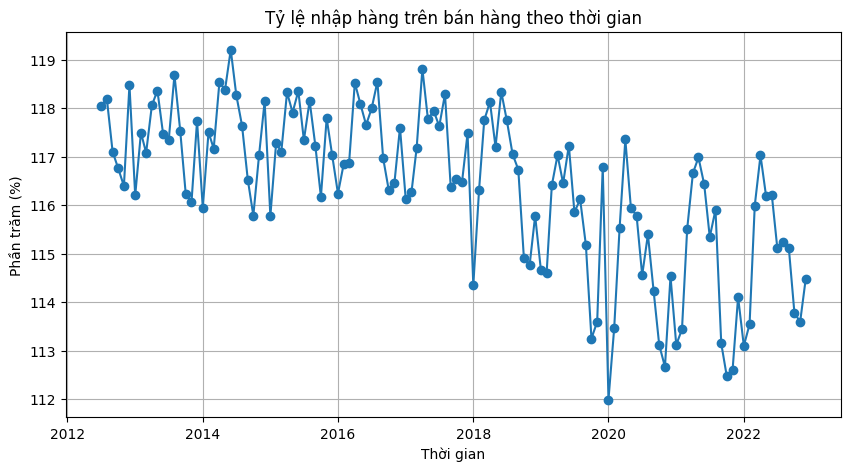

In [16]:
monthly = inventory.groupby(['year', 'month'])[['units_received', 'units_sold']].sum().reset_index()
monthly['received_to_sold_pct'] = monthly['units_received'] / monthly['units_sold'] * 100

plt.figure(figsize=(10,5))
plt.plot(pd.to_datetime(monthly['year'].astype(str) + '-' + monthly['month'].astype(str)), monthly['received_to_sold_pct'], marker='o')
plt.title('Tỷ lệ nhập hàng trên bán hàng theo thời gian')
plt.ylabel('Phần trăm (%)')
plt.xlabel('Thời gian')
plt.grid(True)
plt.show()

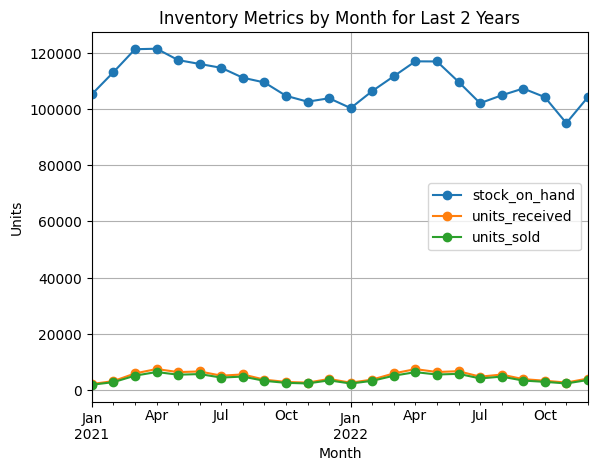

In [12]:
# Aggregate inventory metrics by day for the last 2 years
inv_2years_daily = inventory[inventory['year'].isin(latest_years)]
agg_daily = inv_2years_daily.groupby('snapshot_date')[['stock_on_hand', 'units_received', 'units_sold']].sum()
print(agg_daily)

# agg.plot(kind='line', marker='o')
# plt.title('Inventory Metrics for 2 Latest Years')
# plt.ylabel('Units')
# plt.xlabel('Year')
# plt.grid(True)
# plt.show()
agg_daily.plot(kind='line', marker='o')
plt.title('Inventory Metrics by Month for Last 2 Years')
plt.ylabel('Units')
plt.xlabel('Month')
plt.grid(True)
plt.show()



### Câu chuyện 1: Nghịch lý Khuyến mãi - Bán nhiều nhưng có lãi không và có hàng để giao? (Marketing vs. Supply Chain)
- Câu chuyện này phân tích sự lệch pha giữa nỗ lực kéo traffic của Marketing và khả năng đáp ứng của Vận hành (Operations).

- Bảng dữ liệu kết nối:** `promotions` + `web_traffic` + `order_items` + `inventory` + `reviews`.

- Descriptive (Cái gì đã xảy ra): Biểu diễn sự gia tăng đột biến của lượng truy cập và doanh thu trong các ngày có chiến dịch khuyến mãi lớn
- Diagnostic (Tại sao lại xảy ra):** Dù tỷ lệ chuyển đổi tăng, nhưng hãy chú ý xem `stockout_flag` (cờ báo hết hàng) trong bảng `inventory` có bị kích hoạt không. Chuyện gì xảy ra khi khách đặt hàng nhưng hệ thống hết hàng? Kiểm tra xem điểm đánh giá (`rating`) trong `reviews` có giảm sút hay không do khách hàng phàn nàn.
- Predictive (Điều gì có khả năng xảy ra): Ước tính số lượng đơn hàng bị mất (Lost Sales) và mức độ sụt giảm uy tín nếu tình trạng đứt gãy chuỗi cung ứng này tiếp diễn trong kỳ khuyến mãi tiếp theo.
- Prescriptive (Đề xuất kinh doanh): Đề xuất số ngày dự trữ tồn kho (`days_of_supply`) an toàn cho các sản phẩm chủ lực (hero products) trước kỳ sale. Đề xuất quy tắc tự động tắt quảng cáo (traffic_source) cho các sản phẩm có `sell_through_rate` (tỷ lệ hàng đã bán) chạm ngưỡng 90% để tránh trải nghiệm xấu.


### Câu chuyện 2: Đãi cát tìm vàng - Nhận diện "Khách hàng Giá trị cao" vs "Thợ săn Khuyến mãi" (Customer Analytics)
- Chia phân khúc khách hàng để đầu tư tiền bạc 1 cách hợp lý

- Bảng dữ liệu kết nối:** `customers` + `orders` + `order_items` + `web_traffic`.

- Descriptive:Phân luồng tệp khách hàng theo `acquisition_channel` (kênh tiếp thị) và `age_group` (nhóm tuổi), xem nhóm nào mang lại nhiều đơn hàng nhất.
- Diagnostic: Tính toán tỷ lệ phần trăm đơn hàng áp dụng khuyến mãi (`promo_id` khác null). So sánh xem kênh `organic_search` hay `social_media` mang lại lượng khách hàng mua nguyên giá (full-price) cao hơn. Ai là người chỉ mua khi có mã giảm giá?
- Predictive:** Phân tích `inter-order gap` (số ngày giữa hai lần mua) để dự đoán thói quen mua sắm. Khách hàng từ kênh X sẽ rời bỏ (churn) nếu trong 90 ngày không có chiến dịch giảm giá?
- Prescriptive:** Đề xuất tái phân bổ ngân sách: Giảm tiền chạy quảng cáo cho nhóm "thợ săn khuyến mãi" (chỉ làm giảm biên lợi nhuận), tập trung ngân sách chăm sóc (loyalty program) cho tệp khách hàng mua nguyên giá hoặc khách hàng mua qua các kênh có `bounce_rate` (tỷ lệ thoát) thấp.

Câu chuyện 4: Rủi ro Dòng tiền và Hành vi Thanh toán (Fintech & Cash Flow Analytics)
Câu chuyện này tập trung vào dòng tiền thực tế và rủi ro hủy đơn, một vấn đề cực kỳ đau đầu trong thương mại điện tử ở Việt Nam.

Bảng dữ liệu kết nối: orders + payments + returns + products.

Descriptive: Thống kê tỷ trọng các phương thức thanh toán (payment_method: ví dụ COD, thẻ tín dụng, trả góp). So sánh Giá trị trung bình đơn hàng (AOV) giữa các phương thức này.

Diagnostic: Phương thức nào có tỷ lệ hủy đơn (order_status = 'cancelled') hoặc trả hàng cao nhất? Thông thường, thanh toán khi nhận hàng (COD) mang rủi ro "bùng hàng" rất cao. Thêm vào đó, hãy kiểm tra xem nhóm khách hàng mua trả góp (installments > 1) có xu hướng mua các sản phẩm ở phân khúc cao cấp (segment = 'Premium') nhiều hơn không.

Predictive: Giả lập dòng tiền thực nhận (Net Revenue) sẽ biến động ra sao nếu tỷ lệ thanh toán COD tiếp tục duy trì ở mức cao và đi kèm với tỷ lệ hoàn hàng hiện tại.

Prescriptive: Đề xuất chiến dịch dịch chuyển hành vi thanh toán: Cung cấp mã giảm giá nhỏ hoặc freeship đặc biệt để khuyến khích thanh toán trước (Credit Card/Ví điện tử) nhằm giảm thiểu rủi ro dòng tiền. Đồng thời, đề xuất mở rộng tích hợp các cổng thanh toán "Mua trước trả sau" (Buy Now Pay Later) cho các nhóm sản phẩm giá cao để kích cầu.

Câu chuyện 6: Trải nghiệm Giao hàng và Ranh giới của Sự Rời bỏ (Logistics & Customer Retention)
Khách hàng mua một món đồ đẹp nhưng nếu chờ quá lâu, họ có thể sẽ không bao giờ quay lại.

Bảng dữ liệu kết nối: geography + orders + shipments + reviews + customers.

Descriptive: Vẽ biểu đồ bản đồ (Map visual) hoặc Heatmap để xem phân bổ doanh thu theo khu vực (region, city). Hiển thị thời gian giao hàng trung bình (khoảng cách từ ship_date đến delivery_date) và phí vận chuyển (shipping_fee) theo từng vùng.

Diagnostic: Có mối tương quan nào giữa thời gian giao hàng dài/phí vận chuyển cao với những đánh giá tiêu cực (rating thấp) trong bảng reviews không? Liệu những khách hàng ở vùng bị giao hàng chậm có "inter-order gap" (khoảng thời gian giữa 2 lần mua) dài hơn bình thường, hay thậm chí là không bao giờ quay lại mua lần 2?

Predictive: Phân tích độ co giãn: Nếu rút ngắn thời gian giao hàng xuống 1 ngày ở vùng Central/South, dự kiến tỷ lệ khách hàng quay lại (Retention Rate) sẽ tăng thêm bao nhiêu %?

Prescriptive: Dựa trên chi phí vận chuyển và thời gian giao hàng, đề xuất ban giám đốc cân nhắc mở thêm một Hub trung chuyển (Fulfillment Center) tại khu vực có mật độ đơn hàng cao nhưng thời gian giao hàng đang bị nghẽn. Nếu chưa đủ ngân sách mở kho, cần đàm phán lại SLA (cam kết dịch vụ) với đơn vị vận chuyển thứ ba (3PL) cho các tuyến đường trọng điểm này.